##### Cancer statistics have long been both unsettling and fascinating, and the global data I have analyzed here offers a glimpse into these trends. My exploration will combine multiple datasets to uncover patterns in cancer incidence and mortality rates across countries. 

In [1]:
# Import Libraries and Setup
import warnings 
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg') # Use non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg') # If only plt is imported

import seaborn as sns

%matplotlib inline

# Set a default figure size for plots
plt.rcParams['figure.figsize'] = (10,6)

print('Libraries imported and backend set.')

Libraries imported and backend set.


In [2]:
# Data loading and inspection 
# Load the various CSV files

## Overall global cancer mortality (2022).csv
df_mortality_global = pd.read_csv("Overall global cancer mortality (2022).csv", encoding='Windows-1254')
df_mortality_global.columns = df_mortality_global.columns.str.strip()

## Global cancer incidence in males and females (2022).csv
df_incidence_gender = pd.read_csv("Global cancer incidence in males and females (2022).csv", encoding='Windows-1254')
df_incidence_gender.columns = df_incidence_gender.columns.str.strip()

## Cancer frequency.csv
df_cancer_frequency = pd.read_csv("Cancer frequency.csv", encoding='Windows-1254')
df_cancer_frequency.columns = df_cancer_frequency.columns.str.strip()

## Overall global cancer incidence (2022).csv
df_incidence_global = pd.read_csv("Overall global cancer incidence (2022).csv", encoding='Windows-1254')
df_incidence_global.columns = df_incidence_global.columns.str.strip()

## Global cancer mortality in males and females (2022).csv
df_mortality_gender = pd.read_csv("Global cancer mortality in males and females (2022).csv", encoding='Windows-1254')
df_mortality_global.columns = df_mortality_global.columns.str.strip()

# Inspect dataframes
print('Global Cancer Mortality (2022) Sample:')
print(df_mortality_global.head())

print('\nGlobal Cancer Incidence in Males and Females (2022) Sample:')
print(df_incidence_gender.head())

print('\nCancer Frequency Sample:')
print(df_cancer_frequency.head())

print('\nGlobal Cancer Incidence (2022) Sample:')
print(df_incidence_global.head())

print('\nGlobal Cancer Mortality in Males and Females (2022) Sample:')
print(df_mortality_gender.head())

Global Cancer Mortality (2022) Sample:
     Country Including NMSC Number  Including NMSC Rate Excluding NMSC Number  \
0  ÿMongolia                 4,929                181.5                 4,923   
1  ÿZimbabwe                11,739                144.0                11,599   
2   ÿHungary                32,482                143.7                32,245   
3    ÿPoland               119,992                133.1               118,982   
4   ÿRomania                56,216                132.5                55,627   

   Excluding NMSC Rate  
0                181.3  
1                142.1  
2                142.9  
3                132.4  
4                131.5  

Global Cancer Incidence in Males and Females (2022) Sample:
          Country Male Including NMSC Number  Male Including NMSC Rate  \
0      ÿAustralia                    116,363                     514.3   
1    ÿNew Zealand                     20,562                     473.4   
2  ÿUnited States                  1,283,

In [3]:
# Data cleaning and preprocessing

# For our predictor model, we merge the 'Cancer frequency.csv' and 'Overall global cancer incidence (2022).csv'

# Converting potential numeric columns that might be in string format
df_incidence_global['Including NMSC Rate'] = pd.to_numeric(df_incidence_global['Including NMSC Rate'], errors = 'coerce')
df_incidence_global['Excluding NMSC Rate'] = pd.to_numeric(df_incidence_global['Excluding NMSC Rate'], errors='coerce')

# Merging the datasets on 'Country'
df_merged = pd.merge(df_cancer_frequency, df_incidence_global[['Country', 'Including NMSC Rate', 'Excluding NMSC Rate']], on='Country', how='inner')

print('Merged Data Sample:')
print(df_merged.head())

# Dropping any rows with missing numeric data
df_merged.dropna(inplace=True)
print('\nAfter dropping missing values: {} rows remaining.'.format(df_merged.shape[0]))

Merged Data Sample:
          Country  Cancer rate  Including NMSC Rate  Excluding NMSC Rate
0      ÿAustralia        468.0                462.5                322.4
1    ÿNew Zealand        438.1                427.3                299.9
2        ÿIreland        373.7                344.7                307.0
3        ÿHungary        368.1                336.7                321.2
4  ÿUnited States        352.2                367.0                303.6

After dropping missing values: 43 rows remaining.


## Exploratory Data Analysis

##### In this section, I visualize the data using a variety of techniques. Notice the use of heatmaps to visualize correlation among numeric variables, histograms for distribution, and several other plots.

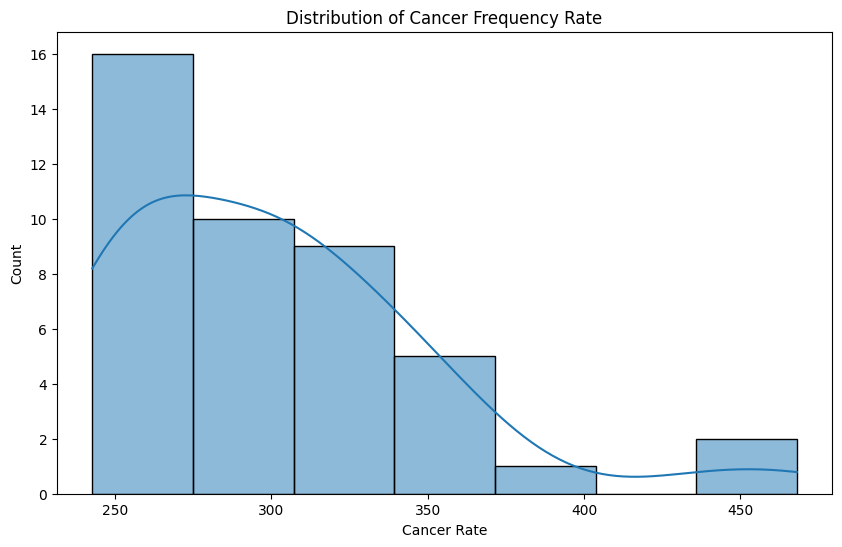

In [5]:
# Histogram for cancer rate
sns.histplot(df_merged['Cancer rate'], kde=True)
plt.title('Distribution of Cancer Frequency Rate')
plt.xlabel('Cancer Rate')
plt.ylabel('Count')
plt.show()

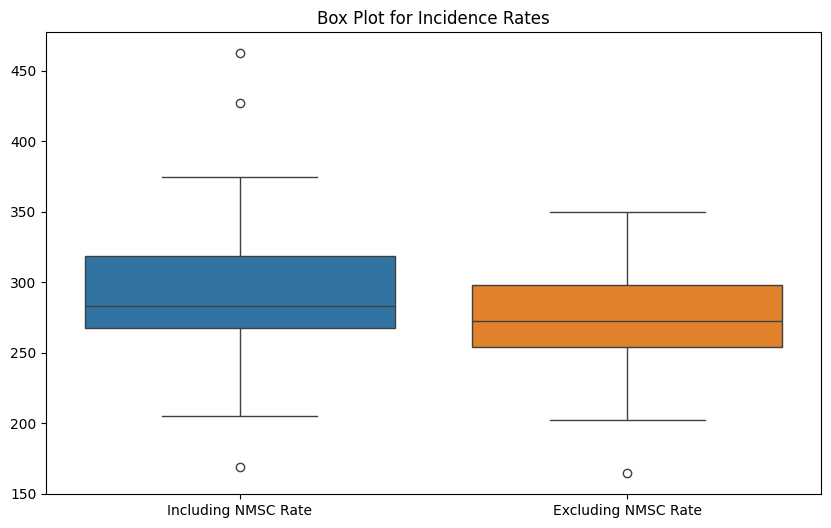

In [8]:
# Box plot for the incidence rate
sns.boxplot(data = df_merged[['Including NMSC Rate', 'Excluding NMSC Rate']])
plt.title('Box Plot for Incidence Rates')
plt.show()

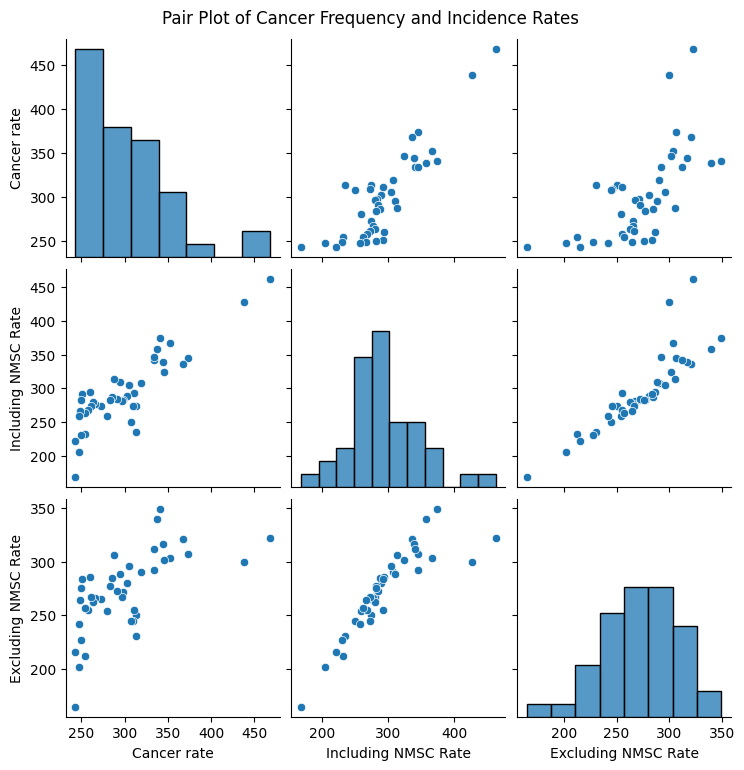

In [9]:
# Pair plot of the merged features
sns.pairplot(df_merged[['Cancer rate', 'Including NMSC Rate', 'Excluding NMSC Rate']])
plt.suptitle('Pair Plot of Cancer Frequency and Incidence Rates', y=1.02)
plt.show()

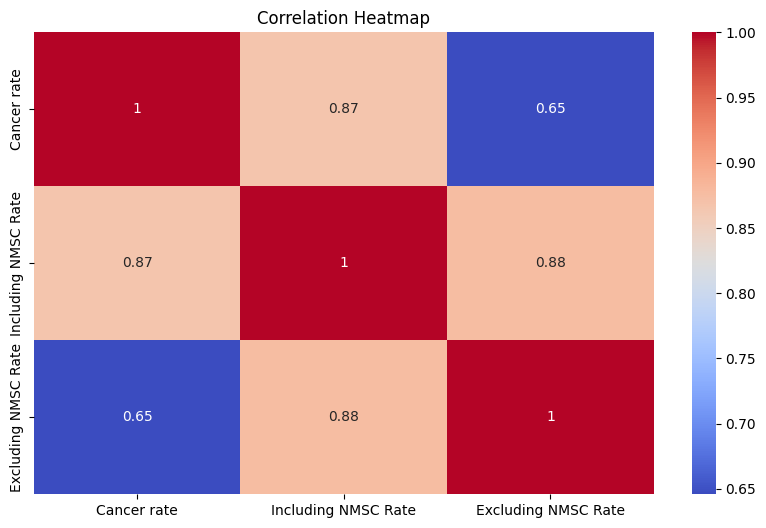

In [10]:
# Correlation heatmap
numeric_df = df_merged.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap for Numeric Features')
    plt.show()
else:
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

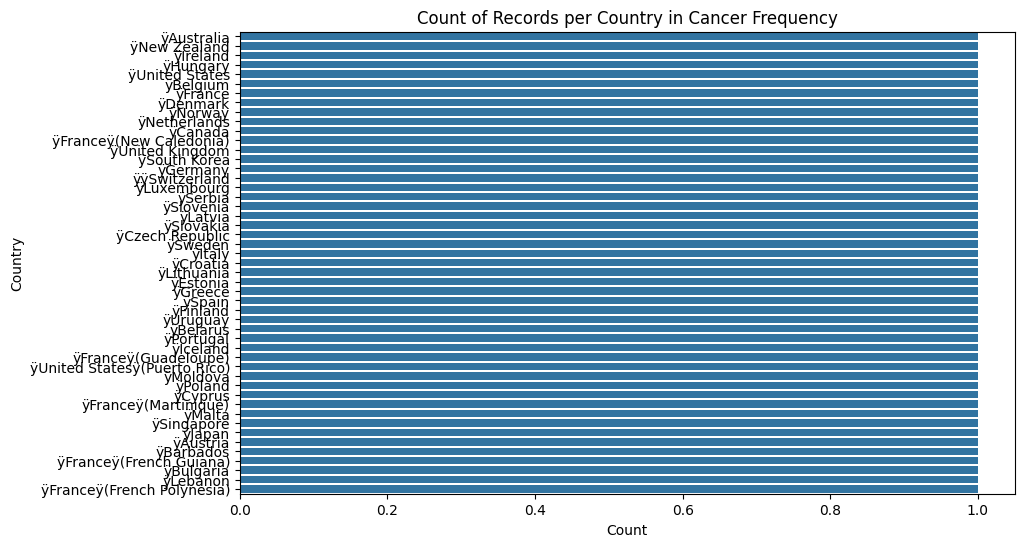

In [11]:
# Countplot for country frequencies in the cancer frequency dataset
plt.Figure(figsize=(12,6))
sns.countplot(y='Country', data=df_cancer_frequency, order=df_cancer_frequency['Country'].value_counts().index)
plt.title('Count of Records per Country in Cancer Frequency')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

## Predictor Model

##### In continuation of our curiosity-driven analysis, I attempted to predict the overall cancer frequency rate based on incidence rates. I used a simple linear regression model from scikit-learn to predict the 'Cancer rate' using 'Including NMSC Rate' and 'Excluding NMSC Rate'. Any errors encountered with data conversion have been addressed in the preprocessing step. Our evaluation metric is the R² score. A modest score may imply that incidence rates do capture some variance in overall frequency, but further investigation might consider more sophisticated models or additional features.

R^2 Score of the Predictor Model: 0.527


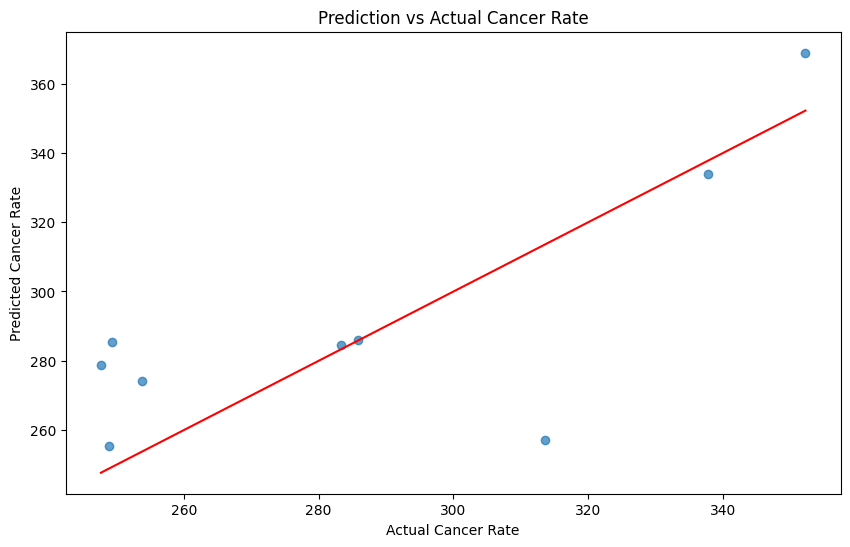

In [15]:
# Predictor model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define features and target
X = df_merged[['Including NMSC Rate', 'Excluding NMSC Rate']]
y = df_merged['Cancer rate']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the testing set
y_pred = model.predict(X_test)

# Calculate prediction accuracy usinf R^2 score
score = r2_score(y_test, y_pred)
print('R^2 Score of the Predictor Model: {:.3f}'.format(score))

# Visualize the prediction vs actual values
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Cancer Rate')
plt.ylabel('Predicted Cancer Rate')
plt.title('Prediction vs Actual Cancer Rate')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red')
plt.show()

#### I combined several datasets, performed thorough cleaning, and extracted insights through various plots. The simple linear regression predictor suggests that incidence rates are moderately predictive of overall cancer frequency.